In [2]:
#Importing libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

#Loading dataset
dataset=load_dataset("lukebarousse/data_jobs")
df=dataset['train'].to_pandas()

#Cleaning data
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)

In [81]:
df_country=df[df['job_country']=='India'].copy()
df_IND=df_country.explode('job_skills')

In [24]:
df_skill_count=df_IND.groupby(['job_skills','job_title_short']).size()
df_skill_count=df_skill_count.reset_index(name='skill_count')
df_skill_count.sort_values(by='skill_count',ascending=False,inplace=True)

In [26]:
job_titles=df_IND['job_title_short'].unique().tolist()
job_titles=sorted(job_titles[:3])


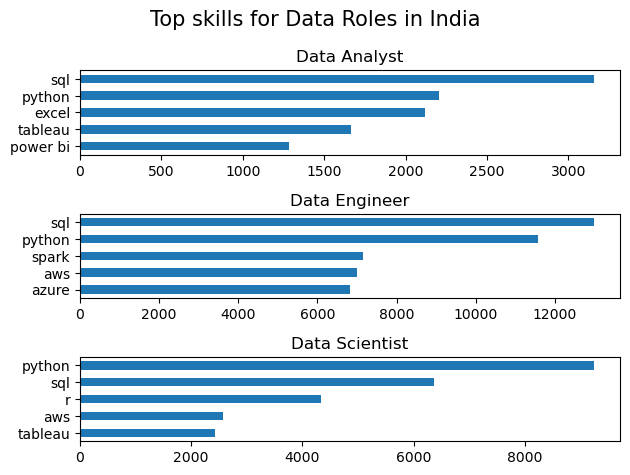

In [39]:
fig,ax=plt.subplots(len(job_titles),1)

for i,title in enumerate(job_titles):
    df_plot=df_skill_count[df_skill_count['job_title_short']==title].head(5)
    df_plot.plot(kind='barh',x='job_skills',y='skill_count',ax=ax[i],title=title,legend=False)
    ax[i].set_ylabel('')
    ax[i].invert_yaxis()

fig.suptitle('Top skills for Data Roles in India',fontsize=15)
fig.tight_layout()

In [82]:
df_job_count=df_country['job_title_short'].value_counts().reset_index(name='job_count')

df_skill_perc=pd.merge(df_skill_count,df_job_count,how='left',on='job_title_short')
df_skill_perc['skill_perc']=100*(df_skill_perc['skill_count']/df_skill_perc['job_count'])


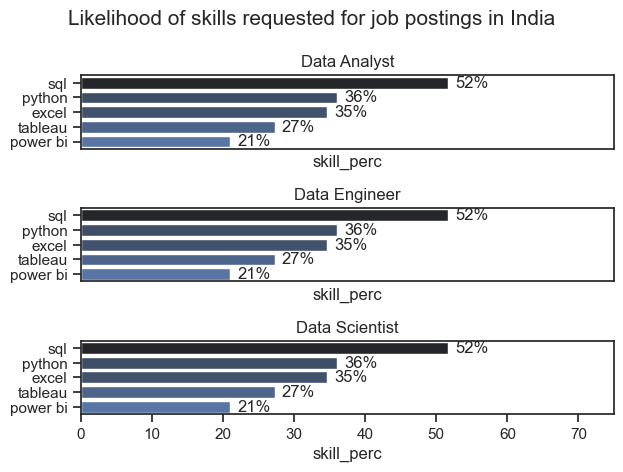

In [101]:
fig,ax=plt.subplots(len(job_titles),1)

sns.set_theme(style='ticks')
for i,job_title in enumerate(job_titles):
    df_plot=df_skill_perc[df_skill_perc['job_title_short']==title].head(5)
    sns.barplot(data=df_plot,x='skill_perc',y='job_skills',ax=ax[i],hue='skill_count',palette='dark:b_r',legend=False)
    ax[i].set_ylabel('')
    ax[i].set_title(job_title)
    ax[i].set_xlim(0,75)

    for n,v in enumerate(df_plot['skill_perc']):
        ax[i].text(v +1,n,f'{v:.0f}%',va='center')

    if i!=len(job_titles)-1:
        ax[i].set_xticks([])
fig.suptitle('Likelihood of skills requested for job postings in India',fontsize=15)
fig.tight_layout()
plt.show()
